# Install Required Libraries

In [1]:
# No installation required

# Import Required Libraries

In [2]:
import os
import shutil
import random
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

random.seed(42)

# Mount Google Drive

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Extract Working Dataset

In [ ]:
# !unzip -q "/content/drive/MyDrive/DataSet/Working_Dataset" -d /content/

# Define Dataset Paths

In [11]:
WORKING_DIR = "/content/drive/MyDrive/DataSet/Working_Dataset/Working_Dataset"

NORMAL_DIR = os.path.join(WORKING_DIR, "Normal")
GLAUCOMA_DIR = os.path.join(WORKING_DIR, "Glaucoma")

OUTPUT_DIR = "/content/Dataset"

# Create Dataset Directories

In [12]:
for split in ["Train", "Validation", "Test"]:
    for cls in ["Normal", "Glaucoma"]:
        os.makedirs(os.path.join(OUTPUT_DIR, split, cls), exist_ok=True)

print("Folders Created Successfully.")

Folders Created Successfully.


# Load Image Paths

In [13]:
normal_images = [
    os.path.join(NORMAL_DIR, img)
    for img in os.listdir(NORMAL_DIR)
]

glaucoma_images = [
    os.path.join(GLAUCOMA_DIR, img)
    for img in os.listdir(GLAUCOMA_DIR)
]

print("Normal :", len(normal_images))
print("Glaucoma :", len(glaucoma_images))

Normal : 791
Glaucoma : 564


# Split Dataset (70% Train, 10% Validation, 20% Test)

In [14]:
def split_images(image_list):

    train, temp = train_test_split(
        image_list,
        test_size=0.30,
        random_state=42,
        shuffle=True
    )

    val, test = train_test_split(
        temp,
        test_size=2/3,
        random_state=42,
        shuffle=True
    )

    return train, val, test


normal_train, normal_val, normal_test = split_images(normal_images)

glaucoma_train, glaucoma_val, glaucoma_test = split_images(glaucoma_images)

# Copy Images into Train, Validation and Test Folders

In [15]:
def copy_images(image_list, destination):

    for img in image_list:
        shutil.copy(img, destination)


copy_images(normal_train,
            os.path.join(OUTPUT_DIR, "Train", "Normal"))

copy_images(normal_val,
            os.path.join(OUTPUT_DIR, "Validation", "Normal"))

copy_images(normal_test,
            os.path.join(OUTPUT_DIR, "Test", "Normal"))

copy_images(glaucoma_train,
            os.path.join(OUTPUT_DIR, "Train", "Glaucoma"))

copy_images(glaucoma_val,
            os.path.join(OUTPUT_DIR, "Validation", "Glaucoma"))

copy_images(glaucoma_test,
            os.path.join(OUTPUT_DIR, "Test", "Glaucoma"))

print("Dataset Split Completed Successfully.")

Dataset Split Completed Successfully.


# Verify Dataset Distribution

In [16]:
def count_images(folder):
    return len(os.listdir(folder))


for split in ["Train","Validation","Test"]:

    normal = count_images(
        os.path.join(OUTPUT_DIR, split, "Normal")
    )

    glaucoma = count_images(
        os.path.join(OUTPUT_DIR, split, "Glaucoma")
    )

    print("="*40)
    print(split)
    print("-"*40)
    print("Normal    :", normal)
    print("Glaucoma  :", glaucoma)
    print("Total     :", normal+glaucoma)

Train
----------------------------------------
Normal    : 553
Glaucoma  : 394
Total     : 947
Validation
----------------------------------------
Normal    : 79
Glaucoma  : 56
Total     : 135
Test
----------------------------------------
Normal    : 159
Glaucoma  : 114
Total     : 273


# Visualize Dataset Distribution

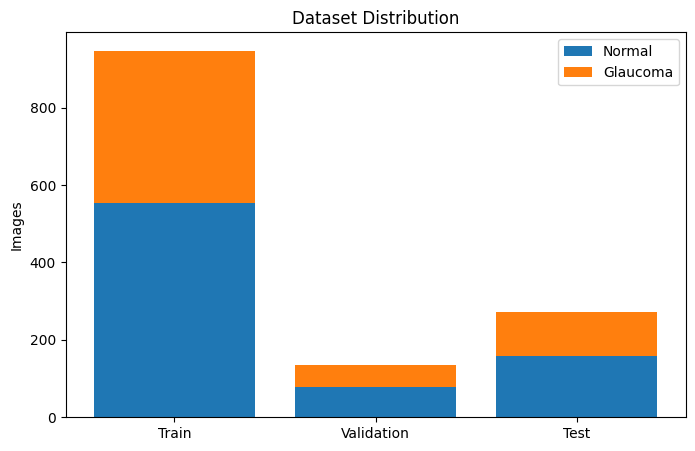

In [17]:
splits = ["Train","Validation","Test"]

normal = []
glaucoma = []

for s in splits:

    normal.append(
        len(os.listdir(os.path.join(OUTPUT_DIR,s,"Normal")))
    )

    glaucoma.append(
        len(os.listdir(os.path.join(OUTPUT_DIR,s,"Glaucoma")))
    )

x = range(len(splits))

plt.figure(figsize=(8,5))

plt.bar(x, normal, label="Normal")

plt.bar(x, glaucoma,
        bottom=normal,
        label="Glaucoma")

plt.xticks(x, splits)

plt.ylabel("Images")

plt.title("Dataset Distribution")

plt.legend()

plt.show()

# Save Dataset Split

In [18]:
import shutil

shutil.make_archive(
    "/content/Dataset",
    "zip",
    "/content",
    "Dataset"
)

print("Dataset.zip Created Successfully.")

Dataset.zip Created Successfully.


# Download Dataset

In [19]:
from google.colab import files

files.download("/content/Dataset.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>